# Decision Making Under Uncertainty

In [12]:
import numpy as np
import pyomo.environ as pyo
from SystemCharacteristics import get_fixed_data
from PlotsRestaurant import plot_HVAC_results_fixed
import pprint
import matplotlib.pyplot as plt

JSON files created successfully in Data_JSON folder!


## Data

Data is inserted via the "get_fixed_data" function which is in "SystemCharacteristics.py". This file creates all the data necessary to run the code and it´s all gathered in folder called Data_JSON where all data can be seen in a clearer way for fast checking

## Task 1

In [17]:
# ----------------------------------------------------------
# Helper
# ----------------------------------------------------------
def other_room(r: int) -> int:
    return 2 if r == 1 else 1


# ----------------------------------------------------------
# MILP: Optimal-in-hindsight for ONE day (10 hours)
# Uncertain inputs: price[t], occ1[t], occ2[t]
# Fixed inputs: fixed_data from get_fixed_data()
# ----------------------------------------------------------
def solve_day_optimal_in_hindsight(fixed_data: dict,
                                  price: np.ndarray,
                                  occ1: np.ndarray,
                                  occ2: np.ndarray,
                                  v0: int = 0,
                                  solver_preference=("gurobi", "cbc", "glpk"),
                                  tee: bool = False):
    """
    price: length T array (uncertain time series)
    occ1, occ2: length T arrays (uncertain time series)
    v0: initial ventilation status at t=0
    Returns a dict with solution vectors and objective value.
    """

    # ----------------------------------
    # Fixed constants
    # ----------------------------------
    T = fixed_data["num_timeslots"]              # 100*24=2400 for whole dataset, but you can test with T=10 for faster solving
    assert len(price) == T and len(occ1) == T and len(occ2) == T

    R = [1, 2]
    Times = list(range(1, T + 1))                # 1..T for decisions
    Times0 = list(range(0, T + 1))               # 0..T for states

    Pmax = fixed_data["heating_max_power"]
    Pvent = fixed_data["ventilation_power"]
    min_up = fixed_data["vent_min_up_time"]

    # thresholds
    Tlow = fixed_data["temp_min_comfort_threshold"]
    Tok = fixed_data["temp_OK_threshold"]
    Thigh = fixed_data["temp_max_comfort_threshold"]
    Hhigh = fixed_data["humidity_threshold"]

    # coefficients (temp)
    z_exch = fixed_data["heat_exchange_coeff"]
    z_conv = fixed_data["heating_efficiency_coeff"]
    z_loss = fixed_data["thermal_loss_coeff"]
    z_vent = fixed_data["heat_vent_coeff"]
    z_occ  = fixed_data["heat_occupancy_coeff"]

    # coefficients (humidity)
    eta_occ  = fixed_data["humidity_occupancy_coeff"]
    eta_vent = fixed_data["humidity_vent_coeff"]

    Tout = np.array(fixed_data["outdoor_temperature"], dtype=float)
    assert len(Tout) == T

    # initial conditions
    # (your file provides a single indoor temperature; we use same for both rooms)
    T0_init = float(fixed_data["initial_temperature"])
    H0_init = float(fixed_data["initial_humidity"])

    # uncertain occupancy packed
    occ = {1: np.array(occ1, dtype=float), 2: np.array(occ2, dtype=float)}

    # Big-M and epsilon (tune if you know tighter bounds)
    MT = 1e3
    MH = 1e3
    eps = 1e-3

    # -------------------------
    # Build model
    # -------------------------
    m = pyo.ConcreteModel()
    m.R = pyo.Set(initialize=R)
    m.T = pyo.Set(initialize=Times)
    m.T0 = pyo.Set(initialize=Times0)

    # Decisions
    m.p = pyo.Var(m.R, m.T, domain=pyo.NonNegativeReals)  # heating power
    m.v = pyo.Var(m.T0, domain=pyo.Binary)               # ventilation on/off incl t=0
    m.y = pyo.Var(m.T, domain=pyo.Binary)                # startup indicator

    # States
    m.Tr = pyo.Var(m.R, m.T0, domain=pyo.Reals)          # temp room r
    m.H  = pyo.Var(m.T0, domain=pyo.Reals)               # humidity

    # Overrule binaries
    m.b = pyo.Var(m.T, domain=pyo.Binary)                # humidity detector
    m.c = pyo.Var(m.R, m.T, domain=pyo.Binary)           # high-temp detector
    m.a = pyo.Var(m.R, m.T, domain=pyo.Binary)           # low-temp overrule active

    # Fix initial states
    m.v[0].fix(int(v0))
    m.H[0].fix(H0_init)
    for r in R:
        m.Tr[r, 0].fix(T0_init)

    # Heater max
    def heater_max_rule(m, r, t):
        return m.p[r, t] <= Pmax
    m.heater_max = pyo.Constraint(m.R, m.T, rule=heater_max_rule)

    # -------------------------
    # Temperature dynamics (depends on uncertain occupancy)
    # T_{r,t} = T_{r,t-1}
    #         + exch*(T_{other,t-1}-T_{r,t-1})
    #         + loss*(Tout_{t}-T_{r,t-1})
    #         + conv*p_{r,t}
    #         - ventCooling*v_t
    #         + occHeat*occ_{r,t}
    # -------------------------
    def temp_dyn_rule(m, r, t):
        rp = other_room(r)
        return m.Tr[r, t] == (
            m.Tr[r, t-1]
            + z_exch * (m.Tr[rp, t-1] - m.Tr[r, t-1])
            + z_loss * (Tout[t-1] - m.Tr[r, t-1])
            + z_conv * m.p[r, t]
            - z_vent * m.v[t]
            + z_occ  * occ[r][t-1]   # <-- uncertain input enters here
        )
    m.temp_dyn = pyo.Constraint(m.R, m.T, rule=temp_dyn_rule)

    # -------------------------
    # Humidity dynamics (depends on uncertain occupancy)
    # H_t = H_{t-1} + eta_occ*(occ1_t + occ2_t) - eta_vent*v_t
    # -------------------------
    def hum_dyn_rule(m, t):
        occ_sum = occ[1][t-1] + occ[2][t-1]  # <-- uncertain input enters here
        return m.H[t] == m.H[t-1] + eta_occ * occ_sum - eta_vent * m.v[t]
    m.hum_dyn = pyo.Constraint(m.T, rule=hum_dyn_rule)

    # -------------------------
    # Startup y_t = 1 iff v_t=1 and v_{t-1}=0
    # -------------------------
    m.start1 = pyo.Constraint(m.T, rule=lambda m, t: m.y[t] >= m.v[t] - m.v[t-1])
    m.start2 = pyo.Constraint(m.T, rule=lambda m, t: m.y[t] <= m.v[t])
    m.start3 = pyo.Constraint(m.T, rule=lambda m, t: m.y[t] <= 1 - m.v[t-1])

    # Ventilation minimum up-time: if start at t -> keep ON for next min_up hours
    def min_up_rule(m, t, k):
        if t + k <= T:
            return m.v[t + k] >= m.y[t]
        return pyo.Constraint.Skip

    m.min_up = pyo.ConstraintList()
    for t in Times:
        for k in range(0, min_up):  # includes k=0 => v[t] >= y[t]
            m.min_up.add(min_up_rule(m, t, k))

    # -------------------------
    # Humidity overrule (your Big-M logic)
    # If H_t > Hhigh => b_t=1 => v_t >= b_t => v_t=1
    # -------------------------
    m.hum_logic_ub = pyo.Constraint(m.T, rule=lambda m, t: m.H[t] - Hhigh <= MH * m.b[t])
    m.hum_logic_lb = pyo.Constraint(m.T, rule=lambda m, t: m.H[t] - Hhigh >= eps - MH * (1 - m.b[t]))
    m.hum_force    = pyo.Constraint(m.T, rule=lambda m, t: m.v[t] >= m.b[t])

    # -------------------------
    # High temperature overrule: if Tr >= Thigh => heater OFF (p=0)
    # -------------------------
    m.high_logic_ub = pyo.Constraint(m.R, m.T, rule=lambda m, r, t: m.Tr[r, t] - Thigh <= MT * m.c[r, t])
    m.high_logic_lb = pyo.Constraint(m.R, m.T, rule=lambda m, r, t: m.Tr[r, t] - Thigh >= eps - MT * (1 - m.c[r, t]))
    m.high_force    = pyo.Constraint(m.R, m.T, rule=lambda m, r, t: m.p[r, t] <= Pmax * (1 - m.c[r, t]))

    # -------------------------
    # Low temperature overrule: if Tr <= Tlow => force p=Pmax until Tr >= Tok
    # (Simple MILP version consistent with what we discussed)
    # -------------------------
    m.low_logic_ub = pyo.Constraint(m.R, m.T, rule=lambda m, r, t: Tlow - m.Tr[r, t] <= MT * m.a[r, t])
    m.low_logic_lb = pyo.Constraint(m.R, m.T, rule=lambda m, r, t: Tlow - m.Tr[r, t] >= eps - MT * (1 - m.a[r, t]))
    m.low_force    = pyo.Constraint(m.R, m.T, rule=lambda m, r, t: m.p[r, t] >= Pmax * m.a[r, t])

    # Optional: prevent max-heat and forced-off simultaneously
    m.no_conflict = pyo.Constraint(m.R, m.T, rule=lambda m, r, t: m.a[r, t] + m.c[r, t] <= 1)

    # -------------------------
    # Objective (depends on uncertain electricity price)
    # min sum_t price[t]*(p1+p2 + Pvent*v)
    # -------------------------
    def obj_rule(m):
        return sum(
            price[t-1] * (sum(m.p[r, t] for r in R) + Pvent * m.v[t])  # <-- uncertain price enters here
            for t in Times
        )
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    # -------------------------
    # Solve
    # -------------------------
    solved = False
    last_err = None
    for sname in solver_preference:
        try:
            solver = pyo.SolverFactory(sname)
            if solver.available():
                res = solver.solve(m, tee=tee)
                if (res.solver.status == pyo.SolverStatus.ok and
                    res.solver.termination_condition == pyo.TerminationCondition.optimal):
                    solved = True
                    break
        except Exception as ex:
            last_err = ex

    if not solved:
        raise RuntimeError(f"No MILP solver succeeded. Tried {solver_preference}. Last error: {last_err}")

    # -------------------------
    # Extract solution
    # -------------------------
    sol = {
        "objective_cost": float(pyo.value(m.obj)),
        "v":  np.array([pyo.value(m.v[t]) for t in Times], dtype=int),
        "p1": np.array([pyo.value(m.p[1, t]) for t in Times], dtype=float),
        "p2": np.array([pyo.value(m.p[2, t]) for t in Times], dtype=float),
        "T1": np.array([pyo.value(m.Tr[1, t]) for t in Times0], dtype=float),
        "T2": np.array([pyo.value(m.Tr[2, t]) for t in Times0], dtype=float),
        "H":  np.array([pyo.value(m.H[t]) for t in Times0], dtype=float),
    }
    return sol


# ----------------------------------------------------------
# Run optimization for 100 days (10 hours each)
# ----------------------------------------------------------
if __name__ == "__main__":
    fixed = get_fixed_data()
    
    # Extract price and occupancy data
    prices_data = fixed['prices']['nested']
    occ1_data = fixed['occupacy_room_1']['nested']
    occ2_data = fixed['occupacy_room_2']['nested']
    
    # Determine number of days
    num_days = len(prices_data)
    print(f"Running optimization for {num_days} days...\n")
    
    # Store results for all days
    all_results = {}
    
    # Run optimization for each day
    for day in range(num_days):
        try:
            # Extract data for this day
            price = np.array([prices_data[day][t] for t in range(fixed["num_timeslots"])], dtype=float)
            occ1 = np.array([occ1_data[day][t] for t in range(fixed["num_timeslots"])], dtype=float)
            occ2 = np.array([occ2_data[day][t] for t in range(fixed["num_timeslots"])], dtype=float)
            
            # Solve for this day
            sol = solve_day_optimal_in_hindsight(fixed, price, occ1, occ2, v0=0, tee=False)
            all_results[day] = sol
            
            # Print progress
            print(f"Day {day:3d} - Cost: {sol['objective_cost']:8.2f} | v: {sol['v']} | p1_avg: {np.mean(sol['p1']):5.2f} | p2_avg: {np.mean(sol['p2']):5.2f}")
            
        except Exception as e:
            print(f"Day {day}: Error - {str(e)}")
    
    # Summary statistics
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    costs = [all_results[d]['objective_cost'] for d in range(num_days)]
    print(f"Total days: {num_days}")
    print(f"Average daily cost: {np.mean(costs):.2f}")
    print(f"Min daily cost: {np.min(costs):.2f} (Day {np.argmin(costs)})")
    print(f"Max daily cost: {np.max(costs):.2f} (Day {np.argmax(costs)})")
    print(f"Std dev: {np.std(costs):.2f}")
    print(f"Total cost (all days): {np.sum(costs):.2f}")

Running optimization for 101 days...

Day   0 - Cost:    14.06 | v: [0 0 0 0 0 0 0 0 0 0] | p1_avg:  0.80 | p2_avg:  0.80
Day   1 - Cost:    10.21 | v: [0 0 1 1 1 1 1 0 0 0] | p1_avg:  0.45 | p2_avg:  0.44
Day   2 - Cost:    35.71 | v: [1 1 1 1 1 0 0 0 0 0] | p1_avg:  0.31 | p2_avg:  0.57
Day   3 - Cost:    17.40 | v: [0 0 0 1 1 1 1 1 0 0] | p1_avg:  0.42 | p2_avg:  0.66
Day   4 - Cost:    44.71 | v: [0 1 1 1 1 1 1 0 0 0] | p1_avg:  0.43 | p2_avg:  0.46
Day   5 - Cost:    65.32 | v: [0 0 1 1 1 1 1 0 0 1] | p1_avg:  0.29 | p2_avg:  0.43
Day   6 - Cost:    91.58 | v: [0 0 0 1 1 1 1 1 0 0] | p1_avg:  0.27 | p2_avg:  0.48
Day   7 - Cost:    29.36 | v: [0 0 0 1 1 1 1 1 0 0] | p1_avg:  0.41 | p2_avg:  0.43
Day   8 - Cost:   115.56 | v: [0 0 1 1 1 0 0 1 1 1] | p1_avg:  0.34 | p2_avg:  0.42
Day   9 - Cost:    22.05 | v: [0 1 1 1 1 1 0 0 0 0] | p1_avg:  0.33 | p2_avg:  0.61
Day  10 - Cost:    63.64 | v: [1 1 1 1 1 1 0 0 0 0] | p1_avg:  0.39 | p2_avg:  0.43
Day  11 - Cost:    25.38 | v: [0 1 1 1

### Visualization task 1

Plotting arbitrary day 27 and day 97



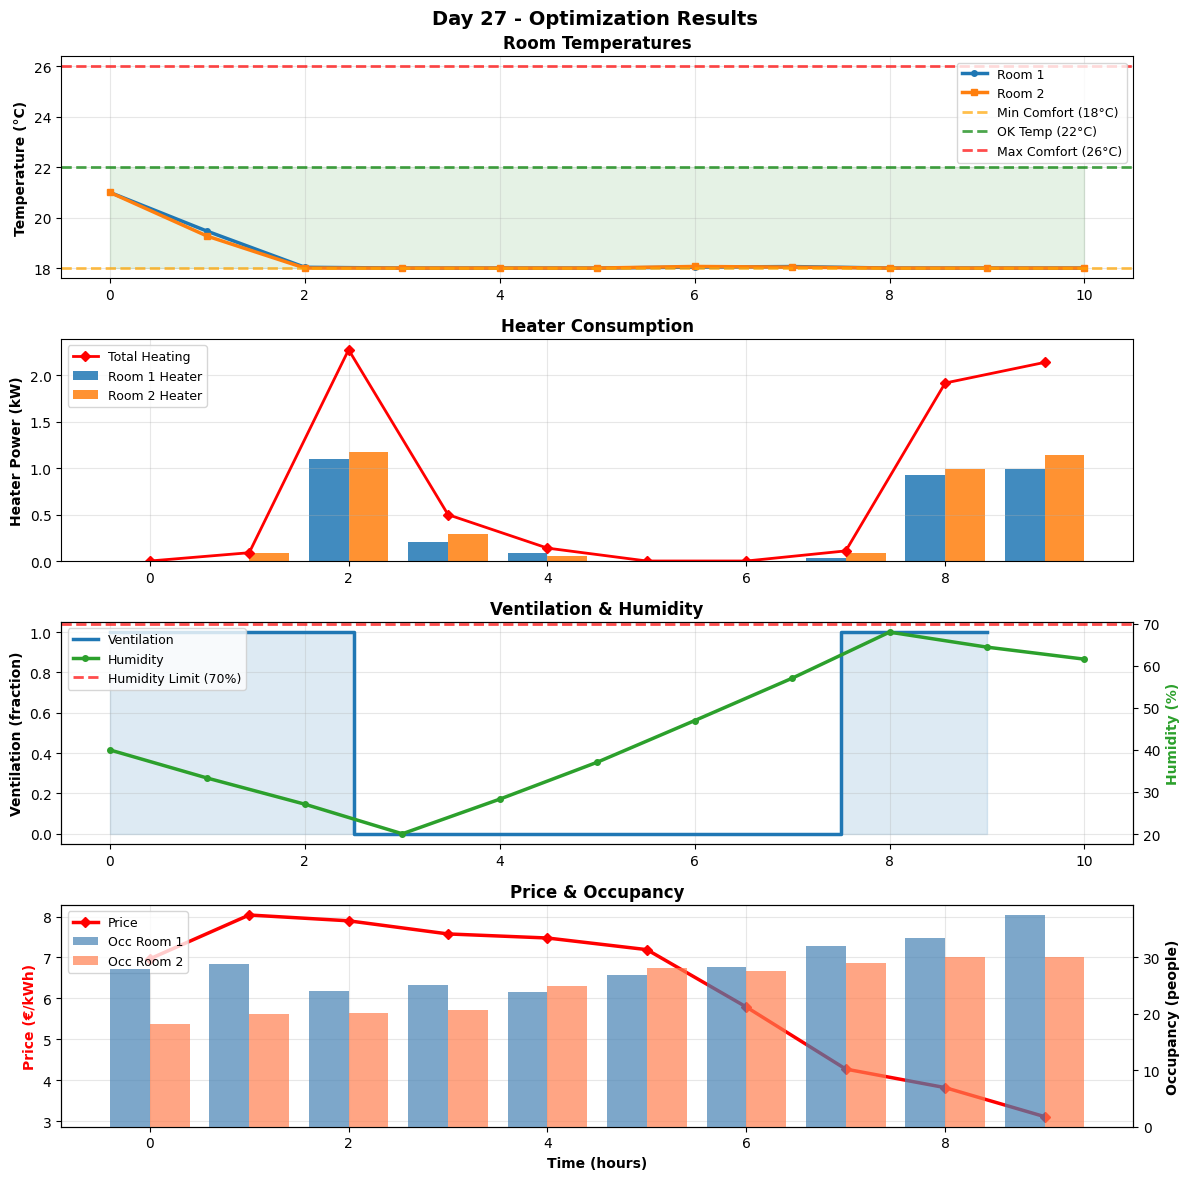

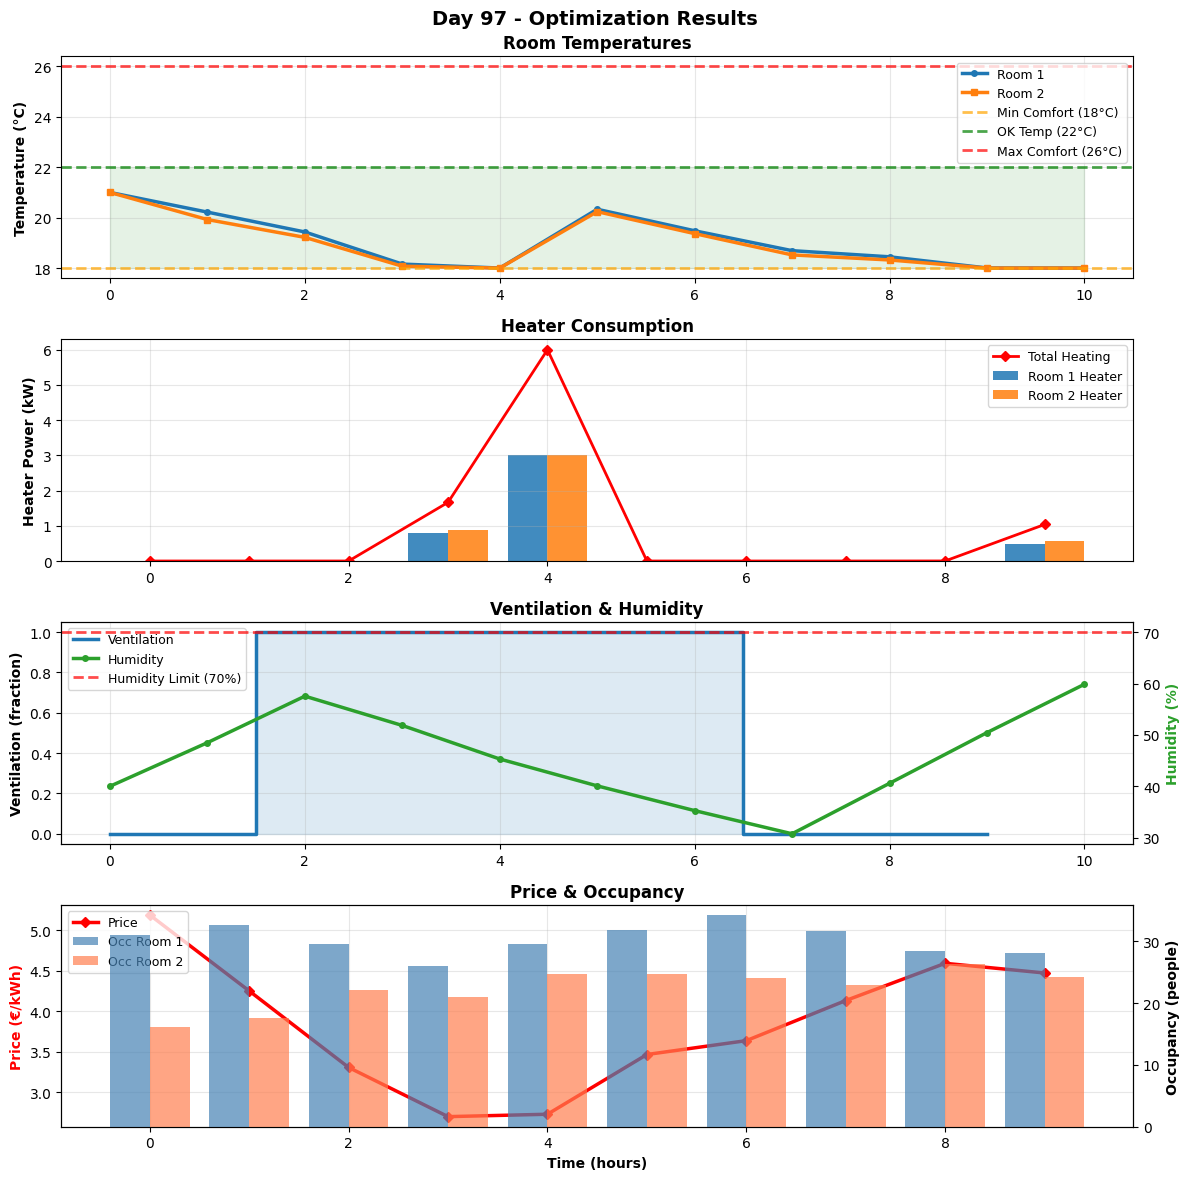

In [26]:
# ===== PLOT TWO ARBITRARY DAYS (27 & 97) =====

try:
    required = ['all_T1', 'all_T2', 'all_H', 'all_p1', 'all_p2', 'all_v', 
                'prices_data', 'occ1_data', 'occ2_data', 'num_days', 'fixed']
    missing = [r for r in required if r not in globals() and r not in locals()]
    if missing:
        raise NameError(f"Missing required variables: {missing}. Run the earlier cells first.")

    # 2 arbitrary days as chosen for the report
    arbitrary_days = [27, 97]
    print(f"Plotting arbitrary day {arbitrary_days[0]} and day {arbitrary_days[1]}\n")

    T_num = fixed["num_timeslots"]
    time_states = np.arange(T_num + 1)
    time_dec = np.arange(T_num)

    # Plot the selected arbitrary days
    for idx, day in enumerate(arbitrary_days):
        sol = all_results[day]
        
        T1 = sol['T1']
        T2 = sol['T2']
        H = sol['H']
        p1 = sol['p1']
        p2 = sol['p2']
        v = sol['v']
        price = np.array([float(prices_data[day][t]) for t in range(T_num)])
        occ1 = np.array([float(occ1_data[day][t]) for t in range(T_num)])
        occ2 = np.array([float(occ2_data[day][t]) for t in range(T_num)])

        fig, axes = plt.subplots(4, 1, figsize=(12, 12))
        fig.suptitle(f'Day {day} - Optimization Results', fontsize=14, fontweight='bold')

        # ===== Temperatures =====
        axes[0].plot(time_states, T1, label='Room 1', color='tab:blue', linewidth=2.5, marker='o', markersize=4)
        axes[0].plot(time_states, T2, label='Room 2', color='tab:orange', linewidth=2.5, marker='s', markersize=4)
        axes[0].axhline(18, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Min Comfort (18°C)')
        axes[0].axhline(22, color='green', linestyle='--', alpha=0.7, linewidth=2, label='OK Temp (22°C)')
        axes[0].axhline(26, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Max Comfort (26°C)')
        axes[0].fill_between(time_states, 18, 22, alpha=0.1, color='green')
        axes[0].set_ylabel('Temperature (°C)', fontweight='bold')
        axes[0].set_title('Room Temperatures', fontweight='bold')
        axes[0].legend(loc='best', fontsize=9)
        axes[0].grid(True, alpha=0.3)

        # ===== Heater consumption =====
        axes[1].bar(time_dec - 0.2, p1, width=0.4, label='Room 1 Heater', color='tab:blue', alpha=0.85)
        axes[1].bar(time_dec + 0.2, p2, width=0.4, label='Room 2 Heater', color='tab:orange', alpha=0.85)
        axes[1].plot(time_dec, p1 + p2, color='red', marker='D', label='Total Heating', linewidth=2, markersize=5)
        axes[1].set_ylabel('Heater Power (kW)', fontweight='bold')
        axes[1].set_title('Heater Consumption', fontweight='bold')
        axes[1].legend(loc='best', fontsize=9)
        axes[1].grid(True, alpha=0.3)

        # ===== Ventilation & Humidity =====
        axes[2].step(time_dec, v, where='mid', label='Ventilation', color='tab:blue', linewidth=2.5)
        axes[2].fill_between(time_dec, 0, v, step='mid', alpha=0.15, color='tab:blue')
        axes[2].set_ylabel('Ventilation (fraction)', fontweight='bold')

        ax2_twin = axes[2].twinx()
        ax2_twin.plot(time_states, H, label='Humidity', color='tab:green', linewidth=2.5, marker='o', markersize=4)
        ax2_twin.axhline(70, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Humidity Limit (70%)')
        ax2_twin.set_ylabel('Humidity (%)', fontweight='bold', color='tab:green')
        axes[2].set_title('Ventilation & Humidity', fontweight='bold')

        lines1, labels1 = axes[2].get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
        axes[2].grid(True, alpha=0.3)

        # ===== Price & Occupancy =====
        axes[3].plot(time_dec, price, color='red', linewidth=2.5, marker='D', label='Price', markersize=5)
        axes[3].set_ylabel('Price (€/kWh)', fontweight='bold', color='red')

        ax3_twin = axes[3].twinx()
        ax3_twin.bar(time_dec - 0.2, occ1, width=0.4, label='Occ Room 1', alpha=0.7, color='steelblue')
        ax3_twin.bar(time_dec + 0.2, occ2, width=0.4, label='Occ Room 2', alpha=0.7, color='coral')
        ax3_twin.set_ylabel('Occupancy (people)', fontweight='bold')
        axes[3].set_xlabel('Time (hours)', fontweight='bold')
        axes[3].set_title('Price & Occupancy', fontweight='bold')

        lines1, labels1 = axes[3].get_legend_handles_labels()
        lines2, labels2 = ax3_twin.get_legend_handles_labels()
        axes[3].legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
        axes[3].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f'Could not plot arbitrary days: {str(e)}')

### Additional interesting visualizations


COMPUTING AVERAGE RESULTS FROM 100 OPTIMIZATION SCENARIOS

Average Results Across 101 Days:

Room 1 Temperature:
  Mean: 19.00°C, Min: 18.02°C, Max: 21.00°C
Room 2 Temperature:
  Mean: 18.94°C, Min: 18.00°C, Max: 21.00°C
Humidity:
  Mean: 45.14%, Min: 37.78%, Max: 61.43%
Room 1 Heating Power:
  Mean: 0.39 kW, Total: 3.94 kWh
Room 2 Heating Power:
  Mean: 0.44 kW, Total: 4.43 kWh
Ventilation:
  Average Hours ON: 5.25 hours/day
Electricity Price:
  Mean: €4.162/kWh, Min: €3.841/kWh, Max: €5.093/kWh
Average Occupancy:
  Room 1: 311.5 person-hours/day
  Room 2: 244.9 person-hours/day


Plotting AVERAGE results for 100 optimization scenarios...


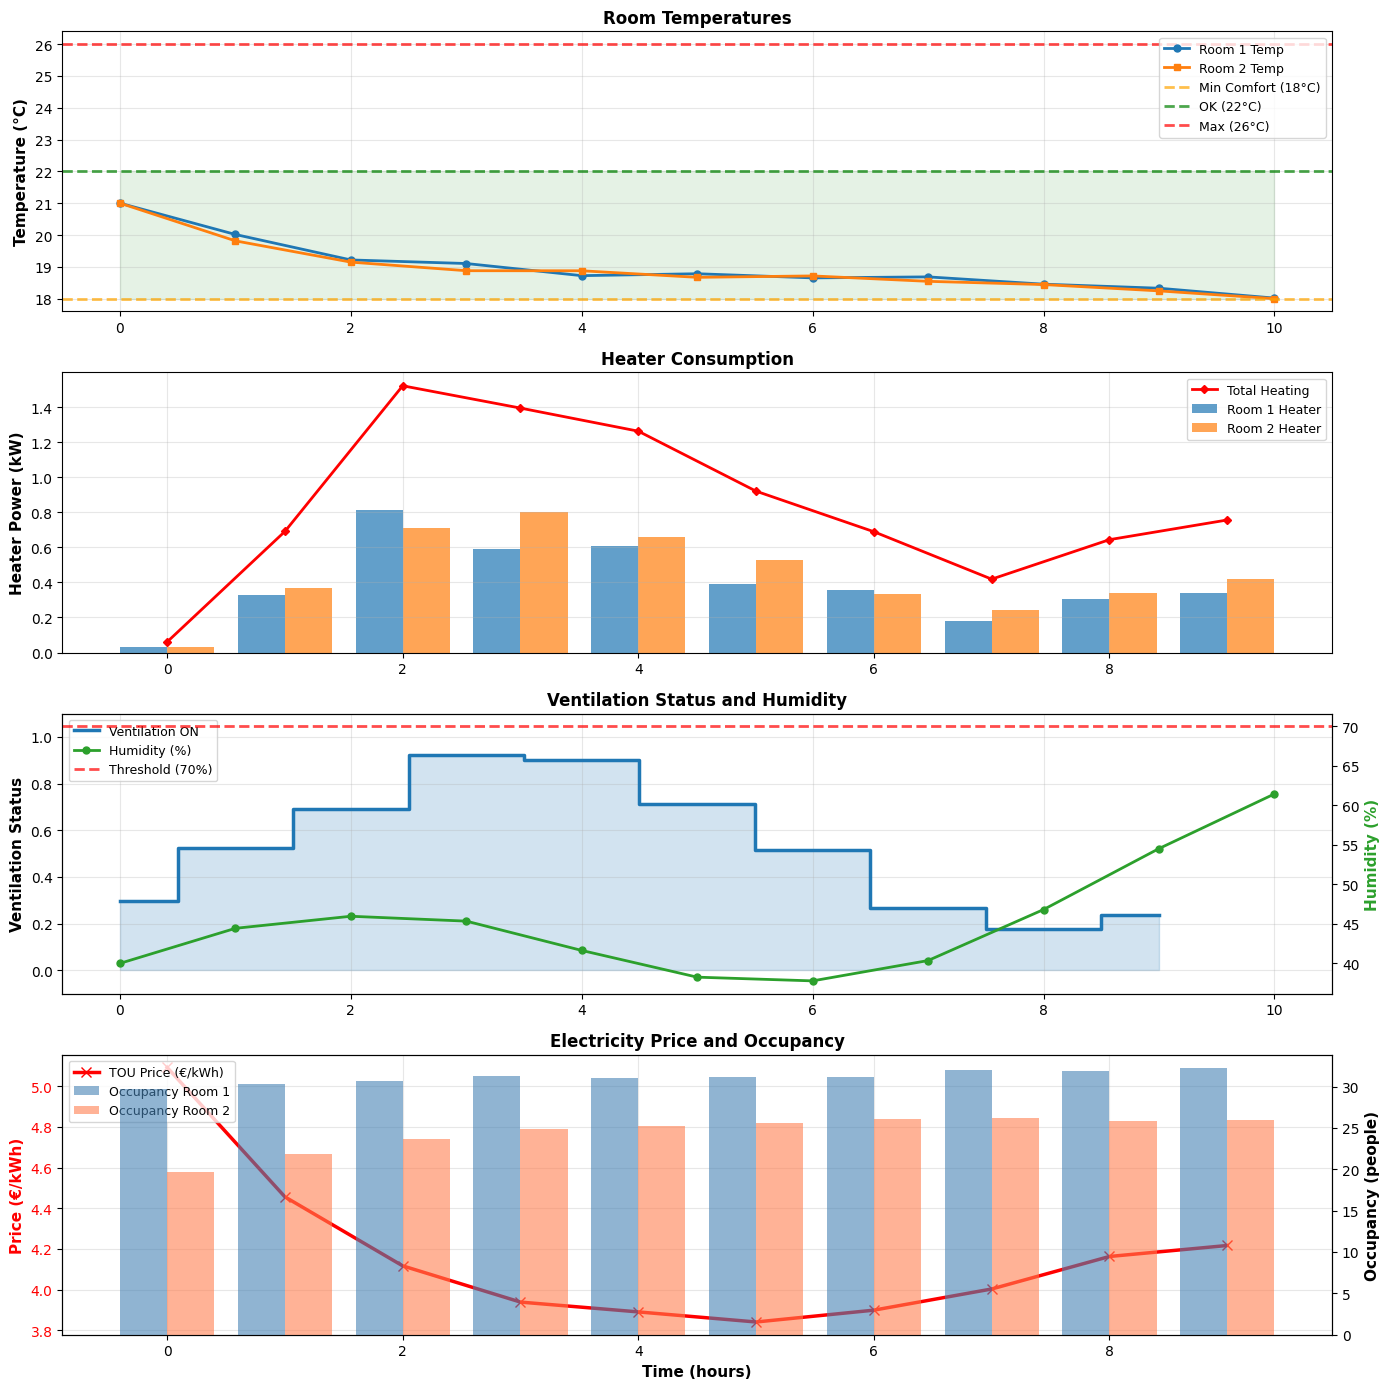

In [27]:
# ===== PLOT AVERAGE RESULTS ACROSS ALL 100 DAYS =====
print("\n" + "="*80)
print("COMPUTING AVERAGE RESULTS FROM 100 OPTIMIZATION SCENARIOS")
print("="*80 + "\n")

# Extract and average all results from the 100 days
T_num = fixed["num_timeslots"]  # 10 time slots
all_T1 = []
all_T2 = []
all_H = []
all_p1 = []
all_p2 = []
all_v = []

for day in range(num_days):
    sol = all_results[day]
    all_T1.append(sol['T1'])
    all_T2.append(sol['T2'])
    all_H.append(sol['H'])
    all_p1.append(sol['p1'])
    all_p2.append(sol['p2'])
    all_v.append(sol['v'])

# Convert to numpy arrays and compute means
all_T1 = np.array(all_T1)  # Shape: (100, 11)
all_T2 = np.array(all_T2)  # Shape: (100, 11)
all_H = np.array(all_H)    # Shape: (100, 11)
all_p1 = np.array(all_p1)  # Shape: (100, 10)
all_p2 = np.array(all_p2)  # Shape: (100, 10)
all_v = np.array(all_v)    # Shape: (100, 10)

# Compute averages (along dimension 0 - across days)
avg_T1 = np.mean(all_T1, axis=0)
avg_T2 = np.mean(all_T2, axis=0)
avg_H = np.mean(all_H, axis=0)
avg_p1 = np.mean(all_p1, axis=0)
avg_p2 = np.mean(all_p2, axis=0)
avg_v = np.mean(all_v, axis=0)

# Compute average price and occupancy across all days
avg_price = np.zeros(T_num)
avg_occ1 = np.zeros(T_num)
avg_occ2 = np.zeros(T_num)

for day in range(num_days):
    for t in range(T_num):
        avg_price[t] += prices_data[day][t]
        avg_occ1[t] += occ1_data[day][t]
        avg_occ2[t] += occ2_data[day][t]

avg_price /= num_days
avg_occ1 /= num_days
avg_occ2 /= num_days

# Print summary statistics
print(f"Average Results Across {num_days} Days:\n")
print(f"Room 1 Temperature:")
print(f"  Mean: {np.mean(avg_T1):.2f}°C, Min: {np.min(avg_T1):.2f}°C, Max: {np.max(avg_T1):.2f}°C")
print(f"Room 2 Temperature:")
print(f"  Mean: {np.mean(avg_T2):.2f}°C, Min: {np.min(avg_T2):.2f}°C, Max: {np.max(avg_T2):.2f}°C")
print(f"Humidity:")
print(f"  Mean: {np.mean(avg_H):.2f}%, Min: {np.min(avg_H):.2f}%, Max: {np.max(avg_H):.2f}%")
print(f"Room 1 Heating Power:")
print(f"  Mean: {np.mean(avg_p1):.2f} kW, Total: {np.sum(avg_p1):.2f} kWh")
print(f"Room 2 Heating Power:")
print(f"  Mean: {np.mean(avg_p2):.2f} kW, Total: {np.sum(avg_p2):.2f} kWh")
print(f"Ventilation:")
print(f"  Average Hours ON: {np.sum(avg_v):.2f} hours/day")
print(f"Electricity Price:")
print(f"  Mean: €{np.mean(avg_price):.3f}/kWh, Min: €{np.min(avg_price):.3f}/kWh, Max: €{np.max(avg_price):.3f}/kWh")
print(f"Average Occupancy:")
print(f"  Room 1: {np.sum(avg_occ1):.1f} person-hours/day")
print(f"  Room 2: {np.sum(avg_occ2):.1f} person-hours/day")
print("\n" + "="*80 + "\n")

# Set up global variables for plotting function
Temp_r1 = avg_T1
Temp_r2 = avg_T2
h_r1 = avg_p1
h_r2 = avg_p2
v = avg_v
Hum = avg_H
price = avg_price
Occ_r1 = avg_occ1
Occ_r2 = avg_occ2
T = np.arange(T_num)

# Call the plot function
print("Plotting AVERAGE results for 100 optimization scenarios...")
plot_HVAC_results_fixed(T,Temp_r1=Temp_r1, Temp_r2=Temp_r2, h_r1=h_r1, h_r2=h_r2, v=v, Hum=Hum, price=price, Occ_r1=Occ_r1, Occ_r2=Occ_r2)

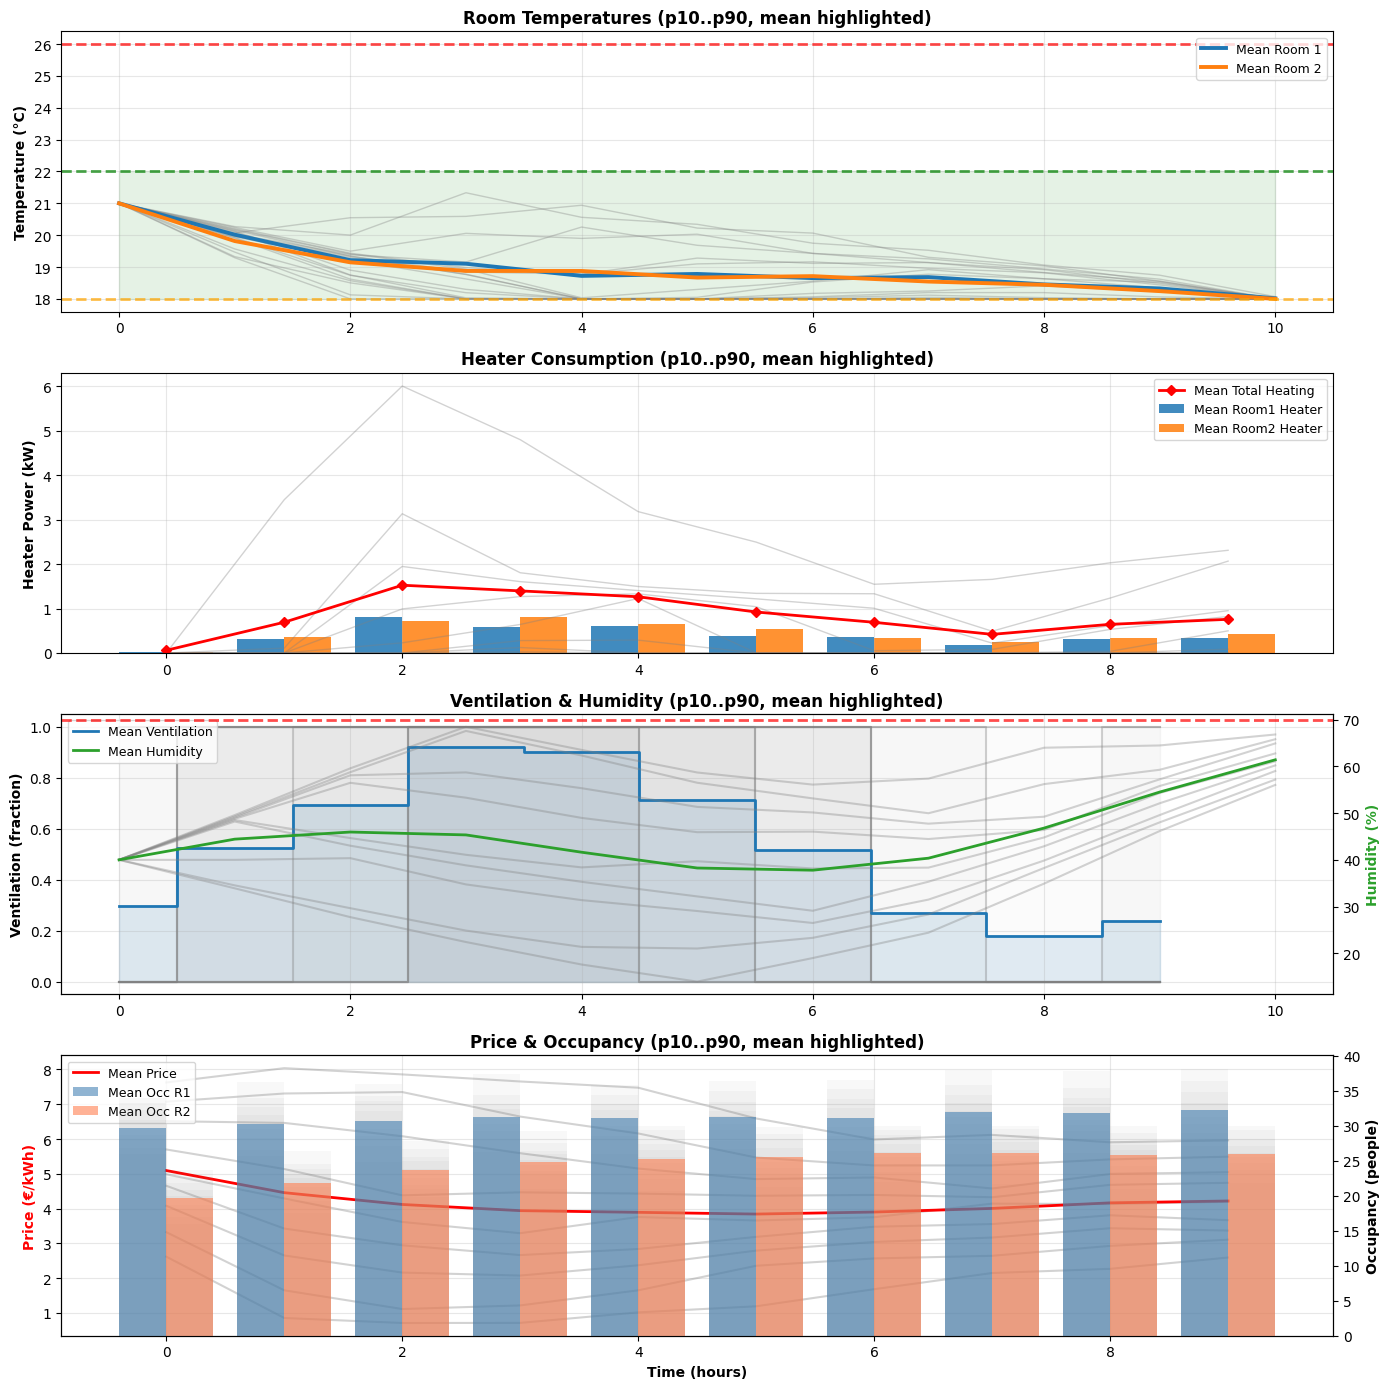

In [28]:
# Plot percentiles (p10..p90) and highlight the scenario average (mean)

try:
    required = ['all_T1','all_T2','all_H','all_p1','all_p2','all_v','prices_data','occ1_data','occ2_data','num_days']
    missing = [r for r in required if r not in globals() and r not in locals()]
    if missing:
        raise NameError(f"Missing required variables: {missing}. Run the earlier cells that compute `all_*` first.")

    n_scen, n_state = all_T1.shape
    n_dec = all_p1.shape[1]
    time_states = np.arange(n_state)
    time_dec = np.arange(n_dec)

    pcts = list(range(10,100,10))  # 10,20,..90

    # Percentiles for temperatures
    perc_T1 = np.percentile(all_T1, pcts, axis=0)   # shape (9, n_state)
    perc_T2 = np.percentile(all_T2, pcts, axis=0)
    perc_H  = np.percentile(all_H,  pcts, axis=0)

    # Percentiles for heaters
    perc_p1 = np.percentile(all_p1, pcts, axis=0)   # shape (9, n_dec)
    perc_p2 = np.percentile(all_p2, pcts, axis=0)

    # Percentiles for ventilation (may be fractional)
    perc_v  = np.percentile(all_v,  pcts, axis=0)

    # Convert nested dicts to numeric arrays (days x hours)
    prices_arr = np.array([[float(prices_data[d][t]) for t in range(n_dec)] for d in range(num_days)])
    occ1_arr   = np.array([[float(occ1_data[d][t]) for t in range(n_dec)] for d in range(num_days)])
    occ2_arr   = np.array([[float(occ2_data[d][t]) for t in range(n_dec)] for d in range(num_days)])

    perc_price = np.percentile(prices_arr, pcts, axis=0)
    perc_occ1  = np.percentile(occ1_arr, pcts, axis=0)
    perc_occ2  = np.percentile(occ2_arr, pcts, axis=0)

    # Compute scenario-wise means (to highlight)
    mean_T1 = np.mean(all_T1, axis=0)
    mean_T2 = np.mean(all_T2, axis=0)
    mean_H  = np.mean(all_H, axis=0)
    mean_p1 = np.mean(all_p1, axis=0)
    mean_p2 = np.mean(all_p2, axis=0)
    mean_v  = np.mean(all_v, axis=0)

    mean_price = np.mean(prices_arr, axis=0)
    mean_occ1  = np.mean(occ1_arr, axis=0)
    mean_occ2  = np.mean(occ2_arr, axis=0)

    fig, axes = plt.subplots(4, 1, figsize=(14, 14))

    # ===== Temperatures =====
    for i in range(len(pcts)):
        axes[0].plot(time_states, perc_T1[i], color='grey', alpha=0.35, linewidth=1)
        axes[0].plot(time_states, perc_T2[i], color='grey', alpha=0.35, linewidth=1)
    # Overlay mean
    axes[0].plot(time_states, mean_T1, label='Mean Room 1', color='tab:blue', linewidth=2.8)
    axes[0].plot(time_states, mean_T2, label='Mean Room 2', color='tab:orange', linewidth=2.8)
    axes[0].axhline(18, color='orange', linestyle='--', alpha=0.7, linewidth=2)
    axes[0].axhline(22, color='green', linestyle='--', alpha=0.7, linewidth=2)
    axes[0].axhline(26, color='red', linestyle='--', alpha=0.7, linewidth=2)
    axes[0].fill_between(time_states, 18, 22, alpha=0.1, color='green')
    axes[0].set_ylabel('Temperature (°C)', fontweight='bold')
    axes[0].set_title('Room Temperatures (p10..p90, mean highlighted)', fontweight='bold')
    axes[0].legend(loc='best', fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # ===== Heater consumption =====
    for i in range(len(pcts)):
        total = perc_p1[i] + perc_p2[i]
        axes[1].plot(time_dec, total, color='grey', alpha=0.35, linewidth=1)
    # Show mean as bars per room and total line
    axes[1].bar(time_dec - 0.2, mean_p1, width=0.4, label='Mean Room1 Heater', color='tab:blue', alpha=0.85)
    axes[1].bar(time_dec + 0.2, mean_p2, width=0.4, label='Mean Room2 Heater', color='tab:orange', alpha=0.85)
    axes[1].plot(time_dec, mean_p1 + mean_p2, color='red', marker='D', label='Mean Total Heating', linewidth=2, markersize=5)
    axes[1].set_ylabel('Heater Power (kW)', fontweight='bold')
    axes[1].set_title('Heater Consumption (p10..p90, mean highlighted)', fontweight='bold')
    axes[1].legend(loc='best', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    # ===== Ventilation & Humidity =====
    for i in range(len(pcts)):
        axes[2].step(time_dec, perc_v[i], where='mid', color='grey', alpha=0.35)
        axes[2].fill_between(time_dec, 0, perc_v[i], step='mid', alpha=0.03, color='grey')
    axes[2].step(time_dec, mean_v, where='mid', label='Mean Ventilation', color='tab:blue', linewidth=2)
    axes[2].fill_between(time_dec, 0, mean_v, step='mid', alpha=0.12, color='tab:blue')

    ax2_twin = axes[2].twinx()
    for i in range(len(pcts)):
        ax2_twin.plot(time_states, perc_H[i], color='grey', alpha=0.35)
    ax2_twin.plot(time_states, mean_H, label='Mean Humidity', color='tab:green', linewidth=2)
    ax2_twin.axhline(70, color='red', linestyle='--', alpha=0.7, linewidth=2)

    axes[2].set_ylabel('Ventilation (fraction)', fontweight='bold')
    ax2_twin.set_ylabel('Humidity (%)', fontweight='bold', color='tab:green')
    axes[2].set_title('Ventilation & Humidity (p10..p90, mean highlighted)', fontweight='bold')
    lines1, labels1 = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    axes[2].grid(True, alpha=0.3)

    # ===== Price & Occupancy =====
    for i in range(len(pcts)):
        axes[3].plot(time_dec, perc_price[i], color='grey', alpha=0.35)
    axes[3].plot(time_dec, mean_price, color='red', linewidth=2, label='Mean Price')
    axes[3].set_ylabel('Price (€/kWh)', fontweight='bold', color='red')

    ax3_twin = axes[3].twinx()
    for i in range(len(pcts)):
        ax3_twin.bar(time_dec - 0.2, perc_occ1[i], width=0.4, alpha=0.05, color='grey')
        ax3_twin.bar(time_dec + 0.2, perc_occ2[i], width=0.4, alpha=0.05, color='grey')
    ax3_twin.bar(time_dec - 0.2, mean_occ1, width=0.4, label='Mean Occ R1', alpha=0.6, color='steelblue')
    ax3_twin.bar(time_dec + 0.2, mean_occ2, width=0.4, label='Mean Occ R2', alpha=0.6, color='coral')

    ax3_twin.set_ylabel('Occupancy (people)', fontweight='bold')
    axes[3].set_xlabel('Time (hours)', fontweight='bold')
    axes[3].set_title('Price & Occupancy (p10..p90, mean highlighted)', fontweight='bold')

    lines1, labels1 = axes[3].get_legend_handles_labels()
    lines2, labels2 = ax3_twin.get_legend_handles_labels()
    axes[3].legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print('Could not produce percentile plot with mean highlighted:', str(e))